# 3. Preprocessing & Labeling

**Objective:** Transform the raw dataset into clean, model-ready inputs.

**Steps:**
1. Load raw data
2. Remove duplicate rows
3. Engineer `Hour` and `LogAmount` features
4. Stratified train / validation / test split (70 / 15 / 15)
5. Scale features (StandardScaler, fit on train only)
6. Save all processed splits + scaler artifacts

> **Why stratified split?** With only 0.17% fraud, a random split could accidentally put nearly all fraud in train or test. Stratified splitting keeps the fraud rate consistent across all three sets.


In [14]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Libraries loaded ✓")


Libraries loaded ✓


## 3.1 Load Raw Dataset

In [15]:
RAW_PATH      = Path("../data/raw/creditcard.csv")
PROCESSED_DIR = Path("../data/processed")
MODELS_DIR    = Path("../models")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(RAW_PATH)
print(f"Raw dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")


Raw dataset shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


## 3.2 Data Quality — Remove Duplicates

In [16]:
before = len(df)
df = df.drop_duplicates()
after  = len(df)
removed = before - after

print(f"Rows before deduplication : {before:,}")
print(f"Rows after  deduplication : {after:,}")
print(f"Duplicate rows removed    : {removed:,} ({removed/before*100:.4f}%)")
print()

# Verify class distribution is preserved
print("Class distribution after deduplication:")
print(df["Class"].value_counts())
print(df["Class"].value_counts(normalize=True).mul(100).round(4))


Rows before deduplication : 284,807
Rows after  deduplication : 283,726
Duplicate rows removed    : 1,081 (0.3796%)

Class distribution after deduplication:
Class
0    283253
1       473
Name: count, dtype: int64
Class
0   99.8333
1    0.1667
Name: proportion, dtype: float64


## 3.3 Feature Engineering

In [17]:
# ── Hour of day (cyclic feature derived from Time) ──────────────────────────────
# Time = seconds elapsed since first transaction in the dataset
# We convert to hour-of-day (0–23) using modulo 24
df["Hour"] = (df["Time"] / 3600) % 24

# ── Log-transformed amount ───────────────────────────────────────────────────────
# Amount is highly right-skewed. log1p compresses large values and stabilises variance.
df["LogAmount"] = np.log1p(df["Amount"])

print("Feature engineering complete:")
print(df[["Time", "Hour", "Amount", "LogAmount", "Class"]].head(8))


Feature engineering complete:
    Time   Hour   Amount  LogAmount  Class
0 0.0000 0.0000 149.6200     5.0148      0
1 0.0000 0.0000   2.6900     1.3056      0
2 1.0000 0.0003 378.6600     5.9393      0
3 1.0000 0.0003 123.5000     4.8243      0
4 2.0000 0.0006  69.9900     4.2625      0
5 2.0000 0.0006   3.6700     1.5412      0
6 4.0000 0.0011   4.9900     1.7901      0
7 7.0000 0.0019  40.8000     3.7329      0


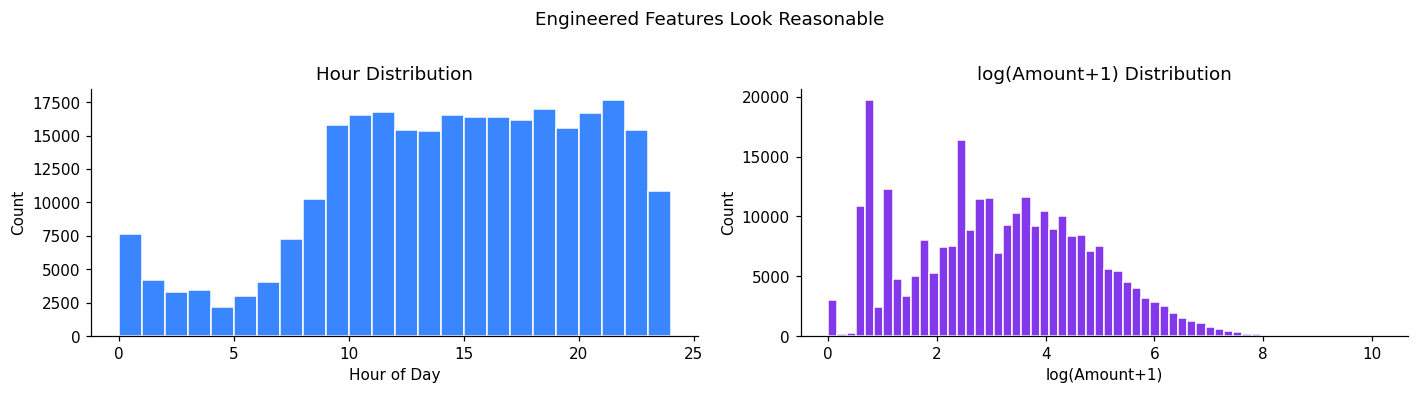

In [18]:
# ── Verify new features look sensible ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

axes[0].hist(df["Hour"], bins=24, color="#3a86ff", edgecolor="white")
axes[0].set_title("Hour Distribution")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Count")

axes[1].hist(df["LogAmount"], bins=60, color="#8338ec", edgecolor="white")
axes[1].set_title("log(Amount+1) Distribution")
axes[1].set_xlabel("log(Amount+1)")
axes[1].set_ylabel("Count")

plt.suptitle("Engineered Features Look Reasonable", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## 3.4 Feature / Target Separation

In [19]:
TARGET_COL  = "Class"

# All columns except target
feature_cols = [c for c in df.columns if c != TARGET_COL]

X = df[feature_cols]
y = df[TARGET_COL]

print(f"Feature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")
print(f"Feature columns ({len(feature_cols)}): {feature_cols}")
print()
print("Target distribution:")
print(y.value_counts())


Feature matrix shape : (283726, 32)
Target vector shape  : (283726,)
Feature columns (32): ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Hour', 'LogAmount']

Target distribution:
Class
0    283253
1       473
Name: count, dtype: int64


## 3.5 Stratified Train / Validation / Test Split

**Split ratios:** 70% train · 15% validation · 15% test

**Why three sets?**
- **Train** — model learns from this
- **Validation** — tune thresholds and hyperparameters (no test data leakage)
- **Test** — final unbiased evaluation


In [20]:
# Step 1: train (70%) vs temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Step 2: validation (15%) vs test (15%) from temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Shapes after split:")
print(f"  X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"  X_val   : {X_val.shape}   y_val   : {y_val.shape}")
print(f"  X_test  : {X_test.shape}   y_test  : {y_test.shape}")


Shapes after split:
  X_train : (198608, 32)   y_train : (198608,)
  X_val   : (42559, 32)   y_val   : (42559,)
  X_test  : (42559, 32)   y_test  : (42559,)


In [21]:
# ── Verify class balance is preserved ───────────────────────────────────────────
split_summary = pd.DataFrame({
    "Split"      : ["Train", "Validation", "Test"],
    "Total"      : [len(y_train), len(y_val), len(y_test)],
    "Normal (0)" : [(y_train==0).sum(), (y_val==0).sum(), (y_test==0).sum()],
    "Fraud (1)"  : [(y_train==1).sum(), (y_val==1).sum(), (y_test==1).sum()],
    "Fraud %"    : [
        f"{y_train.mean()*100:.4f}%",
        f"{y_val.mean()*100:.4f}%",
        f"{y_test.mean()*100:.4f}%"
    ]
})
split_summary


,Split,Total,Normal (0),Fraud (1),Fraud %
0,Train,198608,198277,331,0.1667%
1,Validation,42559,42488,71,0.1668%
2,Test,42559,42488,71,0.1668%


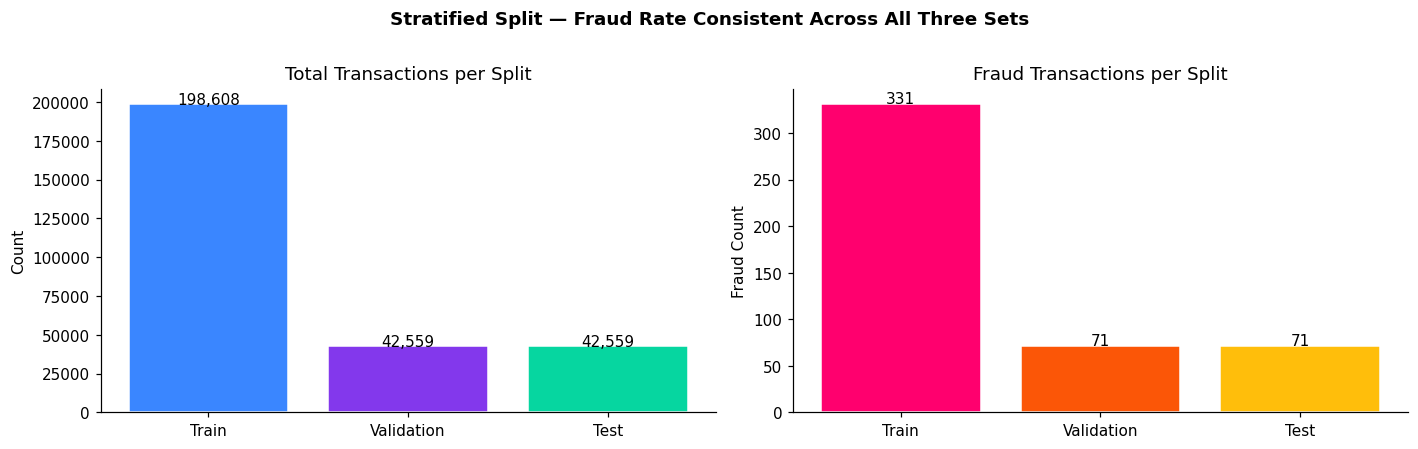

In [22]:
# ── Visualise split sizes ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

splits   = ["Train", "Validation", "Test"]
totals   = [len(y_train), len(y_val), len(y_test)]
fraud_ns = [(y_train==1).sum(), (y_val==1).sum(), (y_test==1).sum()]

axes[0].bar(splits, totals, color=["#3a86ff", "#8338ec", "#06d6a0"],
            edgecolor="white")
axes[0].set_title("Total Transactions per Split")
axes[0].set_ylabel("Count")
for bar, v in zip(axes[0].patches, totals):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+300, f"{v:,}",
                 ha="center", fontsize=10)

axes[1].bar(splits, fraud_ns, color=["#ff006e", "#fb5607", "#ffbe0b"],
            edgecolor="white")
axes[1].set_title("Fraud Transactions per Split")
axes[1].set_ylabel("Fraud Count")
for bar, v in zip(axes[1].patches, fraud_ns):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+1, f"{v}",
                 ha="center", fontsize=10)

plt.suptitle("Stratified Split — Fraud Rate Consistent Across All Three Sets",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## 3.6 Feature Scaling

In [23]:
# ── StandardScaler — fit ONLY on training data ──────────────────────────────────
# Fitting on val/test would leak information about their distribution into the model.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrames for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_val_scaled   = pd.DataFrame(X_val_scaled,   columns=feature_cols, index=X_val.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=feature_cols, index=X_test.index)

print("Scaling complete. Verification (should be ~0 mean, ~1 std on train):")
stats = pd.DataFrame({
    "mean" : X_train_scaled.mean(),
    "std"  : X_train_scaled.std()
}).describe().T
print(stats)


Scaling complete. Verification (should be ~0 mean, ~1 std on train):
       count    mean    std     min     25%     50%    75%    max
mean 32.0000 -0.0000 0.0000 -0.0000 -0.0000 -0.0000 0.0000 0.0000
std  32.0000  1.0000 0.0000  1.0000  1.0000  1.0000 1.0000 1.0000


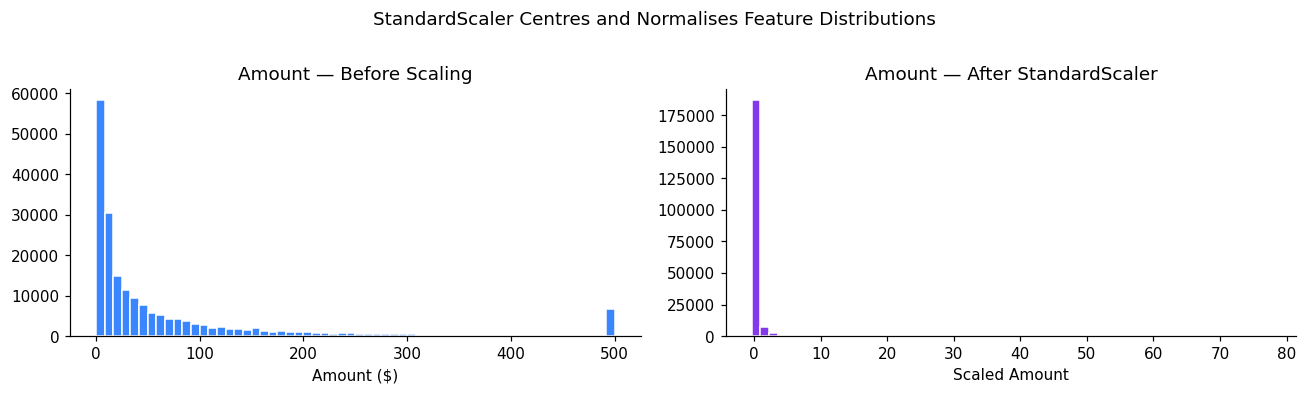

In [24]:
# ── Visual check: before vs after scaling for 'Amount' ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

axes[0].hist(X_train["Amount"].clip(upper=500), bins=60,
             color="#3a86ff", edgecolor="white")
axes[0].set_title("Amount — Before Scaling")
axes[0].set_xlabel("Amount ($)")

axes[1].hist(X_train_scaled["Amount"], bins=60,
             color="#8338ec", edgecolor="white")
axes[1].set_title("Amount — After StandardScaler")
axes[1].set_xlabel("Scaled Amount")

plt.suptitle("StandardScaler Centres and Normalises Feature Distributions",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## 3.7 Save All Processed Files

In [25]:
# ── Save scaled splits (for Logistic Regression, Autoencoder) ───────────────────
X_train_scaled.to_csv(PROCESSED_DIR / "X_train_scaled.csv", index=False)
X_val_scaled.to_csv(  PROCESSED_DIR / "X_val_scaled.csv",   index=False)
X_test_scaled.to_csv( PROCESSED_DIR / "X_test_scaled.csv",  index=False)

# ── Save unscaled splits (for tree-based models that don't need scaling) ─────────
X_train.to_csv(PROCESSED_DIR / "X_train_unscaled.csv", index=False)
X_val.to_csv(  PROCESSED_DIR / "X_val_unscaled.csv",   index=False)
X_test.to_csv( PROCESSED_DIR / "X_test_unscaled.csv",  index=False)

# ── Save labels ──────────────────────────────────────────────────────────────────
y_train.to_csv(PROCESSED_DIR / "y_train.csv", index=False)
y_val.to_csv(  PROCESSED_DIR / "y_val.csv",   index=False)
y_test.to_csv( PROCESSED_DIR / "y_test.csv",  index=False)

# ── Save scaler and feature list (needed by inference / app) ─────────────────────
joblib.dump(scaler,       MODELS_DIR / "scaler.joblib")
joblib.dump(feature_cols, MODELS_DIR / "feature_cols.joblib")

print("✅  All files saved successfully.")
print()
print("Processed files:")
for f in sorted(PROCESSED_DIR.glob("*.*")):
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name:<35}  {size_mb:>7.2f} MB")


✅  All files saved successfully.

Processed files:
  X_test_scaled.csv                      26.92 MB
  X_test_unscaled.csv                    23.98 MB
  X_train_scaled.csv                    125.63 MB
  X_train_unscaled.csv                  111.94 MB
  X_val_scaled.csv                       26.92 MB
  X_val_unscaled.csv                     23.99 MB
  creditcard_eda_features.csv           161.08 MB
  y_test.csv                              0.09 MB
  y_train.csv                             0.40 MB
  y_val.csv                               0.09 MB


## 3.8 Preprocessing Summary

In [26]:
print("=" * 58)
print("  PREPROCESSING SUMMARY")
print("=" * 58)
print(f"  Duplicates removed   : {before - after if 'before' in dir() else 'N/A'}")
print(f"  Features             : {len(feature_cols)} (30 original + 2 engineered)")
print(f"  Engineered features  : Hour, LogAmount")
print()
print("  SPLIT SIZES")
print(f"  Train                : {len(X_train):,} rows ({len(X_train)/after*100:.1f}%)")
print(f"  Validation           : {len(X_val):,} rows ({len(X_val)/after*100:.1f}%)")
print(f"  Test                 : {len(X_test):,} rows ({len(X_test)/after*100:.1f}%)")
print()
print("  FRAUD IN EACH SPLIT")
print(f"  Train fraud          : {(y_train==1).sum()} ({y_train.mean()*100:.4f}%)")
print(f"  Validation fraud     : {(y_val==1).sum()} ({y_val.mean()*100:.4f}%)")
print(f"  Test fraud           : {(y_test==1).sum()} ({y_test.mean()*100:.4f}%)")
print()
print("  ARTIFACTS SAVED")
print("  scaler.joblib        - StandardScaler fit on training data")
print("  feature_cols.joblib  - Ordered list of feature column names")
print("=" * 58)


  PREPROCESSING SUMMARY
  Duplicates removed   : 1081
  Features             : 32 (30 original + 2 engineered)
  Engineered features  : Hour, LogAmount

  SPLIT SIZES
  Train                : 198,608 rows (70.0%)
  Validation           : 42,559 rows (15.0%)
  Test                 : 42,559 rows (15.0%)

  FRAUD IN EACH SPLIT
  Train fraud          : 331 (0.1667%)
  Validation fraud     : 71 (0.1668%)
  Test fraud           : 71 (0.1668%)

  ARTIFACTS SAVED
  scaler.joblib        - StandardScaler fit on training data
  feature_cols.joblib  - Ordered list of feature column names


## Summary

| Step | Decision | Reason |
|---|---|---|
| Remove duplicates | Yes (1,081 rows) | Avoid fitting on repeated data |
| Engineered `Hour` | From `Time / 3600 % 24` | Fraud rate varies by time of day |
| Engineered `LogAmount` | `log1p(Amount)` | Reduces right-skew |
| Split strategy | Stratified 70/15/15 | Preserves rare fraud class in every set |
| Scaler | StandardScaler, fit on train only | Prevents data leakage |
| Unscaled copies saved | Yes | Tree models don't need scaling |

**Next step →** `4_baseline_models.ipynb`
